# Composer Classification (CNN + LSTM)
This notebook contains data exploration and preprocessing steps for the composer classification project. Run the cells below to list MIDI files and convert a MIDI to a piano-roll feature.

In [1]:
import os
import sys
root = os.path.abspath('..')
if root not in sys.path:
    sys.path.insert(0, root)
from src.preprocessing import list_midi_files, load_midi, midi_to_pianoroll

DATA_DIR = os.path.join('..', 'data')
midi_files = list_midi_files(DATA_DIR)
print(f'Found {len(midi_files)} MIDI files')
midi_files[:10]

Found 3938 MIDI files


['..\\data\\Albéniz\\Aragon (Fantasia) Op.47 part 6.mid',
 '..\\data\\Albéniz\\Castilla (Seguidillas) Op.47 part 7.mid',
 '..\\data\\Albéniz\\Cataluna (Curranda), No.2 from Suite Espanola.mid',
 '..\\data\\Albéniz\\Cataluña (Curranda), No.2 from Suite Espanola.mid',
 '..\\data\\Albéniz\\Espana Op. 165.mid',
 '..\\data\\Albéniz\\España Op. 165 No.1.mid',
 '..\\data\\Albéniz\\España Op. 165 No.2.mid',
 '..\\data\\Albéniz\\España Op. 165 No.3.mid',
 '..\\data\\Albéniz\\España Op. 165 No.4.mid',
 '..\\data\\Albéniz\\España Op. 165 No.5.mid']

In [2]:
# Example: load first MIDI and convert to piano-roll (requires pretty_midi)
if len(midi_files) > 0:
    path = midi_files[0]
    print('Loading', path)
    try:
        pm = load_midi(path)
        pr = midi_to_pianoroll(pm, fs=100)
        print('Piano-roll shape:', pr.shape)
    except Exception as e:
        print('Error loading MIDI:', e)
else:
    print('No MIDI files found')

Loading ..\data\Albéniz\Aragon (Fantasia) Op.47 part 6.mid
Piano-roll shape: (128, 25990)


c:\Users\dell\anaconda3\envs\legacy_langchain\lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


## Training (in-notebook)
The cell below performs an in-notebook training run using the same model architecture. It displays composer distribution, trains for a few epochs, saves the model to `../models`, and plots training metrics inline.

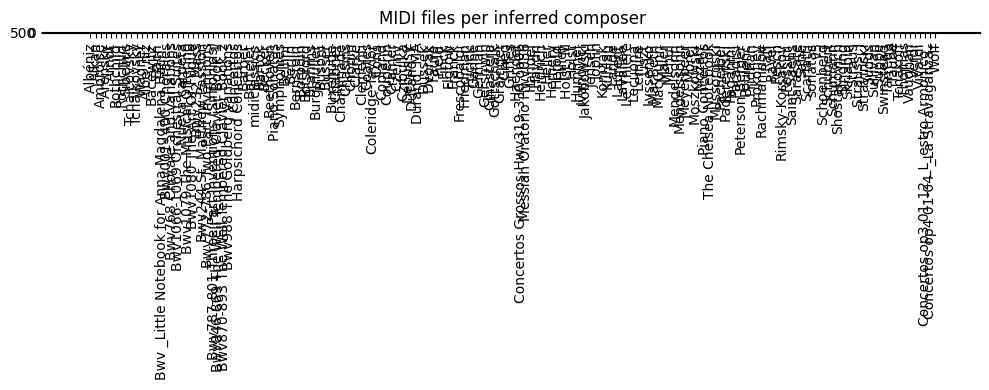

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 500, 32)        │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 250, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 166)            │        21,414 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,470 (1.03 MB)

 Trainable params: 270,470 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 611ms/step - accuracy: 0.4125 - loss: 5.0192 - val_accuracy: 0.0000e+00 - val_loss: 5.1855
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.0000e+00 - loss: 4.2415 - val_accuracy: 0.0000e+00 - val_loss: 6.0332
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.0000e+00 - loss: 5.4482

c:\Users\dell\anaconda3\envs\legacy_langchain\lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.0000e+00 - loss: 4.8857 - val_accuracy: 0.0000e+00 - val_loss: 2.9599
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 358ms/step - accuracy: 0.0000e+00 - loss: 4.7048 - val_accuracy: 0.0000e+00 - val_loss: 2.9149
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - accuracy: 0.2125 - loss: 2.3430 - val_accuracy: 1.0000 - val_loss: 0.4732


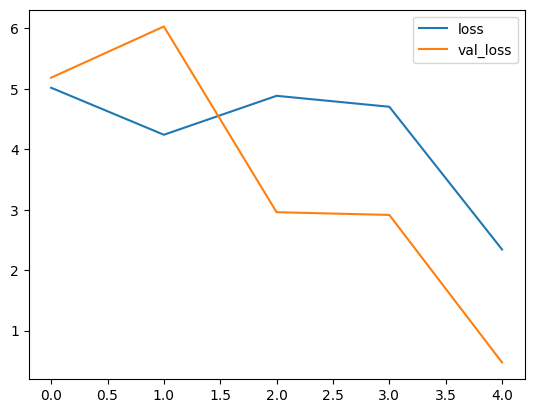

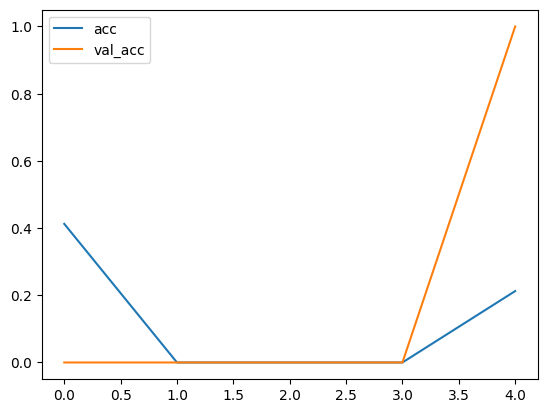

In [3]:
from src.data_generator import build_file_label_list, make_label_map, generator
from src.model import build_cnn_lstm
import collections
import matplotlib.pyplot as plt
import numpy as np
import os

files = build_file_label_list(DATA_DIR)
label_map = make_label_map(files)
inv_map = {v: k for k, v in label_map.items()}

# show composer distribution
counts = collections.Counter([lbl for _, lbl in files])
plt.figure(figsize=(10,4))
plt.bar(list(counts.keys()), list(counts.values()))
plt.xticks(rotation=90)
plt.title('MIDI files per inferred composer')
plt.tight_layout()
plt.show()

# split
split = int(0.8 * len(files))
train_files = files[:split]
val_files = files[split:]

batch_size = 8
time_steps = 500
train_gen = generator(train_files, label_map, batch_size=batch_size, time_steps=time_steps, shuffle=True)
val_gen = generator(val_files, label_map, batch_size=batch_size, time_steps=time_steps, shuffle=False)

model = build_cnn_lstm((time_steps, 128), num_classes=len(label_map))
model.summary()

# For quick demo use small steps; increase for real training
steps_per_epoch = 10
validation_steps = 5

history = model.fit(train_gen, epochs=5, steps_per_epoch=steps_per_epoch, validation_data=val_gen, validation_steps=validation_steps)

os.makedirs(os.path.join('..', 'models'), exist_ok=True)
model.save(os.path.join('..', 'models', 'final_model.h5'))

# plot metrics
plt.figure()
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history.get('accuracy', history.history.get('acc')), label='acc')
plt.plot(history.history.get('val_accuracy', history.history.get('val_acc')), label='val_acc')
plt.legend()
plt.show()

## Evaluation and Visualizations (in-notebook)
This cell loads the saved model, runs predictions on validation segments, prints the classification report, and shows a normalized confusion matrix inline.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from src.data_generator import build_file_label_list, make_label_map, midi_path_to_segments
import os

DATA_DIR = os.path.join('..', 'data')
files = build_file_label_list(DATA_DIR)
label_map = make_label_map(files)
inv_map = {v: k for k, v in label_map.items()}
num_labels = len(label_map)

model_path = os.path.join('..', 'models', 'final_model.h5')
if not os.path.exists(model_path):
    alt = os.path.join('..', 'models', 'best_weights.h5')
    if os.path.exists(alt):
        model_path = alt
    else:
        raise FileNotFoundError('No trained model found in ../models; run training first')

print('Loading model from', model_path)
model = load_model(model_path)

split = int(0.8 * len(files))
val_files = files[split:]
y_true = []
y_pred = []

for path, lbl in val_files:
    try:
        segs = midi_path_to_segments(path, time_steps=time_steps)
    except Exception as e:
        print('Skipping', path, 'error', e)
        continue
    if segs.size == 0:
        continue
    preds = model.predict(segs, verbose=0)
    pidx = preds.argmax(axis=1)
    y_true.extend([label_map[lbl]] * len(pidx))
    y_pred.extend(pidx.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

unique_labels = np.unique(np.concatenate([y_true, y_pred]))
label_names = [inv_map[int(i)] for i in unique_labels]
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=label_names))

cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-9)

plt.figure(figsize=(10,8))
plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Normalized Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(unique_labels))
plt.xticks(tick_marks, label_names, rotation=90)
plt.yticks(tick_marks, label_names)

thresh = cm_norm.max() / 2.
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, format(cm_norm[i, j], '.2f'),
                 horizontalalignment="center",
                 color="white" if cm_norm[i, j] > thresh else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

Loading model from ..\models\final_model.h5


c:\Users\dell\anaconda3\envs\legacy_langchain\lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


ValueError: Number of classes, 30, does not match size of target_names, 166. Try specifying the labels parameter